# Project 1: Transaction Success Prediction


* **Date:** `3/6/2026`

This project analyzes AWS S3 transaction data using the `sklearn` Gaussian Naïve Bayes model as part of the [CNM Ingenuity Data Science Bootcamp](https://deepdivecoding.com/data-science/).

## Problem Definition

Amazon Web Services (AWS), a global cloud platform, services millions of customers daily. Using their [transaction.train.big](https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv) dataset, they want to know **whether or not a future customer will make a transaction based on their historical data**. In data terms, this is a **binary classification problem** because a customer will either purchase an item or not. This project will use the `sklearn` Gaussian Naïve Bayes, a **supervised machine learning model**.



## Data Collection/Sources

### Data Overview

**Date Source:**
1. https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv

## Data Collection

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import plotly as px
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

### File Paths

In [ ]:
orig = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv")
orig.shape

(1050000, 104)

### `.head()` & `.tail()`

In [ ]:
orig.head(5) # get a glimpse at the original df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
orig.tail(5) # ... and the tail

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


### `.describe()`

In [ ]:
orig.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,524999.500000,303109.035663,0.0000,262499.750000,524999.50000,787499.250000,1.049999e+06
target,180000.0,0.100222,0.300297,0.0000,0.000000,0.00000,0.000000,1.000000e+00
var_0,180000.0,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,1.671650e+01
var_1,180000.0,15.870166,3.010492,6.2993,13.830400,15.93460,18.061425,2.607910e+01
var_2,180000.0,12.735619,4.185923,-1.0185,9.664675,12.67070,15.837300,2.699760e+01
...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### `.value_counts()`

In [ ]:
# checking value types and count of the target var
orig["target"].value_counts( dropna = False )

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [ ]:
# checking distribution of target var
orig["target"].value_counts( normalize = True, dropna = False ).mul(100)

,proportion
target,
NaN,82.857143
0.0,15.424762
1.0,1.718095


### `.isna()`

In [ ]:
# return count of NULL values in each row
# how many null values are there?
null_series = orig.isna().sum().sort_values( ascending = False )
null_nonzero = null_series[( null_series != 0 )] # & ( null_series != 1050000 )]
null_nonzero.unique()

array([1050000,  870000])

In [ ]:
null_nonzero.count()

np.int64(102)

In [ ]:
# how many rows are not 100% empty, but still contain NULL values?
null_variation = null_series[( null_series != 0 ) & ( null_series != 1050000 )]
null_variation.count()

np.int64(51)

In [ ]:
# how many rows ARE 100% empty?
null_all = null_series[( null_series == 1050000 )]
null_all.count()

np.int64(51)

In [ ]:
complete_rows = null_series[( null_series == 0 )]
complete_rows # bummer :/

,0
Unnamed: 0,0
ID_code,0


### Initial Observations

* There are **1,050,000 rows** and **104 columns**, including an index.
* The `target` column contains values `0` and `1`. I assume that:
  * `1 == "Transaction"`
  * `0 == "No Transaction"`
    * ... or `TRUE/FALSE` respectively.
* There are only **180,000 rows with `target` values**. The other `1,032,000` will be dropped, since it is not possible to use a Gaussian Naïve Bayes model where *the target variable is unknown.*
  * Even once the `NULL` rows are dropped, the `target` variable will likely have an imbalanced distribution since there are more `FALSE` transactions than `TRUE` ones.
* There are **102 features** with `NULL` values of some kind. Within that, **51 features** are completely empty (n = 1,050,000) and the other **51 features** are somewhat empty (n = 87,000). This is certainly synthetic data.
* Only the `index` and `primary_key` are non-null.

## Data Cleaning

In [ ]:
# make a working copy called 'main'
main = orig.copy()
main.head(5)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# validate existing cols
main.columns

Index(['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3',
       'var_4', 'var_5', 'var_6',
       ...
       'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var_97',
       'var_98', 'var_99', 'var_100'],
      dtype='object', length=104)

In [ ]:
main.shape

(1050000, 104)

In [ ]:
# drop index, primary key, and null_all cols

main = main.dropna( axis = 1, how = 'all' )
main = main.drop(['Unnamed: 0', 'ID_code'], axis=1)

main

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689
1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# check for NULL counts - only 87000 values should be left
series = main.isna().sum().sort_values( ascending = False )
nonzero = series[( series != 0 )] # & ( null_series != 1050000 )]
nonzero.unique()

array([870000])

In [ ]:
# drop rows where target value is NaN
main = main.dropna( axis = 0 )
main

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
# validate
main.shape

(180000, 51)

In [ ]:
# validate
series = main.isna().sum().sort_values( ascending = False )
nonzero = series[( series != 0 )] # & ( null_series != 1050000 )]
nonzero.unique()

array([], dtype=int64)

In [ ]:
# validate target is void of NaN
main["target"].isna().unique()

array([False])

In [ ]:
# checking distribution of target var
main["target"].value_counts( normalize = True, dropna = False ).mul(100)

,proportion
target,
0.0,89.977778
1.0,10.022222


## Exploratory Data Analysis

In [ ]:
# this is the original, unbalanced target distribution
main["target"].value_counts()

,count
target,
0.0,161960
1.0,18040


In [ ]:
import plotly.express as px # I prefer plotly

fig = px.histogram(main, x = "target", marginal = "box")
fig.show()

# main["target"].hist() ; # but here is matplotlib just in case

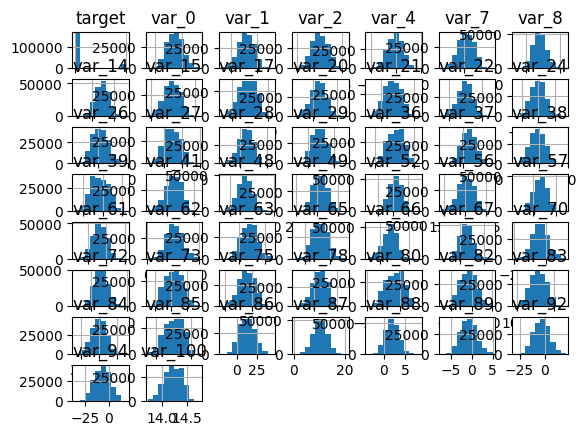

In [ ]:
main.hist() ;

In [ ]:
corr = main.corr()
corr.head(5)

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
target,1.000000,0.045506,-0.051718,-0.046433,0.041593,-0.041987,0.052457,0.045281,-0.057373,-0.054375,...,-0.052324,-0.053733,-0.042073,0.047543,-0.063871,-0.042765,0.059306,0.040520,0.049072,-0.047005
var_0,0.045506,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.051718,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.046433,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,0.041593,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807


In [ ]:
import plotly.express as px

fig = px.imshow(corr,
                text_auto=True, # Display values in cells
                color_continuous_scale='Picnic', # Diverging scale for correlation
                title="Correlation Heatmap of AWS Dataset",
                zmin=-1,
                zmax=1
                )
fig.show()

* Feature correlations don't appear to exceed ~5%.
* However, the `target` variable is imbalanced.
* **The next section proceeds with imbalanced data to compare the outputs against a balanced dataset.**

## Imbalanced Model Prediction

In [ ]:
# validate the data still exists...
main.head(5)

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275


In [ ]:
# make a copy
imbalanced = main.copy()

In [ ]:
# keep features only

X = imbalanced.drop( columns = ["target"] )
y = imbalanced["target"]

In [ ]:
X

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
# coerce as type int to be safe
y = y.astype(int)
y

,target
3,0
5,0
11,0
15,0
19,0
...,...
1049990,0
1049993,0
1049995,1
1049997,0


In [ ]:
# train test split

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
[ _.shape for _ in [X_train, X_test, y_train, y_test] ]

[(144000, 50), (36000, 50), (144000,), (36000,)]

In [ ]:
# model

gnb = GaussianNB()

In [ ]:
# fit

gnb.fit(X_train, y_train) ;

In [ ]:
# predict

y_pred = gnb.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# performance

imbalanced_perf = ( y_test - y_pred ).add(-1).abs().mul(100).mean()
print(round(imbalanced_perf, 2))

93.67


In [ ]:
# multiple cross validation

n = 100
results = np.zeros(n)

for i in range(n):
  ### TSS
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
  X_train, X_test, y_train, y_test

  ### model
  gnb = GaussianNB()

  ### fit
  gnb.fit(X_train,y_train)

  ### prediction
  y_pred = gnb.predict(X_test)

  ### performance
  results[i] = 1-(y_test - y_pred).abs().mean()


In [ ]:
results.mean()*100

np.float64(91.12447222222222)

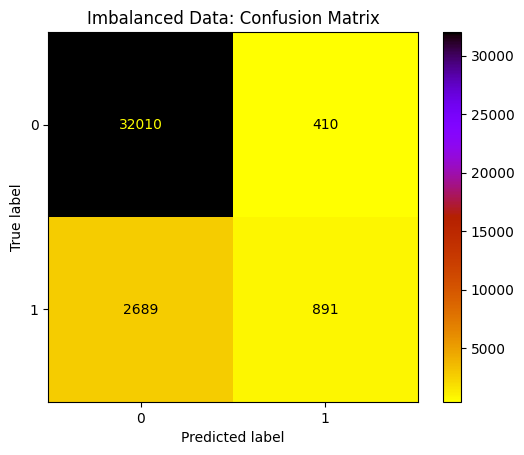

In [ ]:
import matplotlib.pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'gnuplot_r',
    )
plt.grid(False)
plt.title('Imbalanced Data: Confusion Matrix') ;

* **True Positives:** `32,034` - While this appears to be a great number, we know that the `target` variable is *not* balanced and this therefore is not the most reliable indicator of success.
* **False Positives:** `414`
* **True Negatives:** `787`
* **False Negatives:** `2765`

In [ ]:
tp = 32034
tn = 787
fn = 2765
fp = 414

accuracy = ( tp + tn ) / ( tp + fn + fn + tn )
precision = ( tp ) / ( tp + fp )
recall = ( tp ) / ( tp + fn )
f1 = 2 * ( precision * recall ) / ( precision + recall )

print(f'Accuracy: {round(accuracy, 2)*100}%')
print(f'Precision: {round(precision, 2)*100}%')
print(f'Recall: {round(recall, 2)*100}%')
print(f'F-1 Score: {round(f1, 2)*100}%')

Accuracy: 86.0%
Precision: 99.0%
Recall: 92.0%
F-1 Score: 95.0%


**Imbalanced Data: Confusion Matrix Interpretation:**
* **Accuracy:** `86%` - This confirms that the model is not as accurate as the true positive predictions suggest.
* **Precision:** `99%` - This is a very suspicious number.
* **Recall:** `92%`
* **F-1 Score:** `95%`

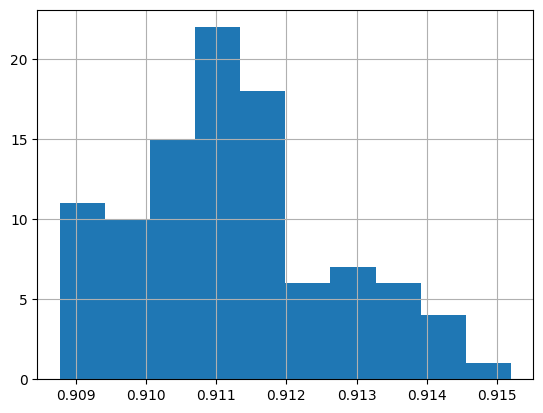

In [ ]:
pd.Series(results).hist() ;

**Imbalanced Target Observations:**
* Initial Model Performance: `93.67%`
* Cross-Validation Model Performance: `91.12%`
* Cross-Validation Model Distribution: Somewhat left-skewed

**Summary**
Without balancing the `target` variable, the Gaussian Naïve Bayes model predicted transactions with 86% accuracy and 99% precision.

## Balanced Model Prediction

In [ ]:
# validate the data still exists...
main.head(5)

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275


In [ ]:
# make a copy
balanced = main.copy()

In [ ]:
balanced["target"].value_counts()

,count
target,
0.0,161960
1.0,18040


In [ ]:
transaction = balanced[balanced["target"] == 1]
no_transaction = balanced[balanced["target"] == 0].sample(n = transaction.shape[0] )
balanced = pd.concat([no_transaction,transaction])
balanced.shape

(36080, 51)

In [ ]:
180000 - 36080

143920

In [ ]:
imbalanced.shape

(180000, 51)

In [ ]:
balanced["target"].value_counts()

,count
target,
0.0,18040
1.0,18040


In [ ]:
# select target and feature set
X_bal = balanced.drop( columns = ["target"] )
y_bal = balanced["target"]
y_bal = y_bal.astype(int)

In [ ]:
# train test split

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.20, random_state=0)
[ _.shape for _ in [X_train_bal, X_test_bal, y_train_bal, y_test_bal] ]

[(28864, 50), (7216, 50), (28864,), (7216,)]

In [ ]:
# model

gnb_bal = GaussianNB()

# fit

gnb_bal.fit(X_train_bal, y_train_bal) ;

# predict

y_pred_bal = gnb_bal.predict(X_test_bal)
y_pred_bal

# performance

balanced_perf = ( y_test_bal - y_pred_bal ).add(-1).abs().mul(100).mean()
print(round(balanced_perf, 2))

98.05


In [ ]:
# multiple cross validation

n = 100
results_bal = np.zeros(n)

for i in range(n):
  ### TSS
  X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.20)
  X_train_bal, X_test_bal, y_train_bal, y_test_bal

  ### model
  gnb_bal = GaussianNB()

  ### fit
  gnb_bal.fit(X_train_bal,y_train_bal)

  ### prediction
  y_pred_bal = gnb_bal.predict(X_test_bal)

  ### performance
  results_bal[i] = 1-(y_test_bal - y_pred_bal).abs().mean()

results_bal.mean()*100

np.float64(75.59866962305986)

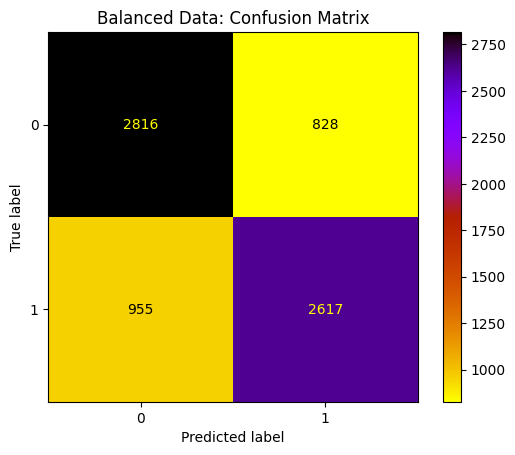

In [ ]:
import matplotlib.pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test_bal,
    y_pred_bal,
    normalize = None,
    values_format = 'd',
    cmap = 'gnuplot_r',
    )
plt.grid(False)
plt.title('Balanced Data: Confusion Matrix') ;

In [ ]:
tp_bal = 2816
tn_bal = 2617
fn_bal = 955
fp_bal = 828

accuracy_bal = ( tp_bal + tn_bal ) / ( tp_bal + fn_bal + fn_bal + tn_bal )
precision_bal = ( tp_bal ) / ( tp_bal + fp_bal )
recall_bal = ( tp_bal ) / ( tp_bal + fn_bal )
f1_bal = 2 * ( precision_bal * recall_bal ) / ( precision_bal + recall_bal )

print(f'Balanced Accuracy: {round(accuracy_bal, 2)*100}%')
print(f'Balanced Precision: {round(precision_bal, 2)*100}%')
print(f'Balanced Recall: {round(recall_bal, 2)*100}%')
print(f'Balanced F-1 Score: {round(f1_bal, 2)*100}%')
print('######################################')
print(f'Imbalanced Accuracy: {round(accuracy, 2)*100}%')
print(f'Imbalanced Precision: {round(precision, 2)*100}%')
print(f'Imbalanced Recall: {round(recall, 2)*100}%')
print(f'Imbalanced F-1 Score: {round(f1, 2)*100}%')

Balanced Accuracy: 74.0%
Balanced Precision: 77.0%
Balanced Recall: 75.0%
Balanced F-1 Score: 76.0%
######################################
Imbalanced Accuracy: 86.0%
Imbalanced Precision: 99.0%
Imbalanced Recall: 92.0%
Imbalanced F-1 Score: 95.0%


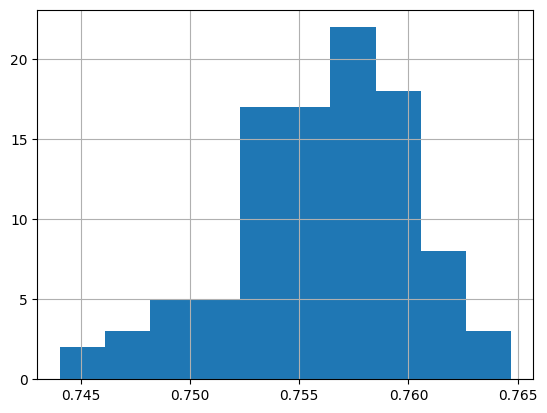

In [ ]:
pd.Series(results_bal).hist() ;

**Balanced Model Performance:**
* Initial Model Performance: `98.05%`
* Cross-Validation Model Performance: `75.59%%`
* Cross-Validation Model Distribution: Somewhat right-skewed

**Summary**

Balancing the dataset dropped **143,920 rows** from the cleaned dataset, so that the model was trained on 36,080 transaction records as opposed to the imbalanced data of 180,000 records.
* This may help explain why some of the metrics decreased despite the initial improvement of the model performance.

**Recommendations & Next Steps**

1. Given the increase in **828** false positive transactions, I would not suggest to AWS that they budget with an expectation of ~800 or so transactions actually occurring over whatever time period this data contains.
2. Collect more features about the dataset, such as when the transaction occurred, for what item, how much it was priced, who the customer is, etc.
3. Investigate features further and attempt other models, including higher `gnb` iterations (`n`) and XGBoost, Random Forest, Regression, etc.
4. Borrowed from classmates: Investigate `qq-plot` and rewrite code into reusable `functions` for efficiency.

*Important Note: The attached slides presentations "role-plays" being employed at AWS as an application of this project.*